# Imports

In [30]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [31]:
import os

import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

# Load data

In [32]:
from eyewire2_functional_analysis import data_loader

In [33]:
  

from eyewire2_functional_analysis.data_loader import DATA_2P
import pandas as pd

data_folder = 'Z:/github/eulerlab/eyewire2-functional-analysis/data/data-2p'

type(pd.read_parquet(os.path.join(data_folder, f'df_eyewire2_roi_level_GCL{3}.parquet')).chirp_trace.iloc[0])

str

In [34]:
df_rois, df_fields, df_outline = data_loader.load_all_dfs()
df = data_loader.load_df_rois_morph(verbose=True)

df_main: dropped 8356 duplicate 'Latest NucID' row(s), 20279 remain
df_map: excluding 2 / 380 ROI(s) with no 'Latest NucID' (not a real cell)
Matched 378 / 378 mapping-sheet ROI(s) to a 2p ROI in df_rois
Joined 376 / 378 mapped ROI(s) to df_main on 'Latest NucID' (2 had no matching row in df_main)


In [35]:
[c for c in df.columns if 'ID' in c]

['Latest NucID',
 'Nuc SupervoxID',
 'Soma SupervoxID',
 'Latest SegID',
 'Proofread NucID',
 'Proofread SegID',
 'Proofread SegID Log',
 'Proofread NucID Log']

### Inspect dataframe

In [36]:
### each row is a cell
df

,Latest NucID,Index,Nuc Coords,Nuc SupervoxID,Soma Coords,Soma SupervoxID,Latest SegID,Proofreader Cell Type Guess,Proofreader 1,Proofreader 2,...,group_id,supergroup,prob_cluster,prob_group,prob_supergroup,prob_class,probs_per_cluster,qfilt,2p-Field,2p-ROI
0,720575940554861467,A43,"50398, 13931, 1258",78955586662247936,"50072, 13937, 1264",78885217918139854,720575940557124706,ON-SAC,Althea Lou,Glenda,...,23,Slow ON,0.789362,0.789362,0.874497,0.929468,"[0.001688096601444819, 0.0016375959626820189, ...",True,GCL4,30
1,720575940572981949,B37,"36716, 21255, 680",77056592507811381,"36746, 21000, 680",77056592507805046,720575940557921829,ON-SAC,Nseraf,Prince,...,42,dAC,0.567364,0.771353,0.884248,0.884248,"[0.0028011801453518823, 0.0024908340206640815,...",True,GCL0,36
2,720575940577751704,D1,"32653, 23923, 553",76493986151462142,"32653, 23923, 583",76493986151527146,720575940568899103,Unknown,Elison,"(Greg, Althea Lou)",...,12,ON-OFF,0.804667,0.819760,0.832646,0.913740,"[0.0020822615335256726, 0.0032838992937911002,...",False,GCL0,1
3,720575940534317101,D2,"33159, 22959, 606",76564217456810156,"33159, 22959, 661",76564217456913467,720575940574776056,NaN,Juliane,Jonathan\nChristine Joy,...,34,dAC,0.605752,0.615440,0.702638,0.702638,"[0.003336756586838654, 0.008818983121221289, 0...",True,GCL0,2
4,720575940554891618,D3,"33787, 21853, 597",76634448762033177,"33787, 21853, 677",76634448762209118,720575940574791163,ON-SAC,Nseraf,Juliane\nGlenda,...,42,dAC,0.772927,0.790771,0.927322,0.927322,"[0.0017071109567420337, 0.0016375104799094017,...",True,GCL0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
371,720575940559161547,E141,"28730, 27160, 259",76001885911302961,"28654, 26971, 382",75931448447948346,720575940558177239,Unknown,Rhosly Jay,April Grace,...,28,Slow ON,0.407219,0.409453,0.506035,0.846763,"[0.0022829924398860228, 0.0021377670432014455,...",True,GCL2,8
372,720575940581392083,E177,"39118, 24485, 623",77408848545416204,"39245, 24635, 637",77408917264861043,720575940556421607,SAC,Cj,Charm,...,42,dAC,0.789306,0.878349,0.927613,0.927613,"[0.001743295222772673, 0.0016255236446178986, ...",True,GCL0,86
373,720575940579434707,D21,"33645, 24480, 456",76634792292428754,"33645, 24480, 491",76634792292518876,720575940559774600,NaN,Enriq,NaN,...,42,dAC,0.665092,0.682904,0.903983,0.903983,"[0.00190230492020636, 0.0019956140038342837, 0...",True,GCL0,22
374,720575940572009658,E2534,"38096, 15181, 1016",77266874173835678,"38096, 15181, 1036",77266874240425536,720575940563667558,Unknown,Glenda,April Grace,...,32,Unc. SbC,0.730012,0.752402,0.774713,0.887935,"[0.002913265670536159, 0.002609855667100161, 0...",True,GCL1,42


In [37]:
### raw and preprocessed ("pp") traces for the chirp
df[['chirp_trace', 'chirp_trace_t0', 'chirp_trace_dt',
    'chirp_pp_trace', 'chirp_pp_trace_t0', 'chirp_pp_trace_dt', 
    'chirp_qidx',
    'chirp_pres_qidx', 
    'chirp_average_norm', 'chirp_average_dt',
    'chirp_snippets', 'chirp_snippets_t0', 'chirp_snippets_dt',
    'chirp_triggertimes_snippets']]

,chirp_trace,chirp_trace_t0,chirp_trace_dt,chirp_pp_trace,chirp_pp_trace_t0,chirp_pp_trace_dt,chirp_qidx,chirp_pres_qidx,chirp_average_norm,chirp_average_dt,chirp_snippets,chirp_snippets_t0,chirp_snippets_dt,chirp_triggertimes_snippets
0,"[11045.73076923077, 11036.73076923077, 11042.4...",0.044,0.128,"[1.1028164625167847, -0.33053940534591675, 0.5...",0.044,0.128,0.648772,0.666667,"[0.019929855259703647, 0.01644467734477757, 0....",0.016667,"[[-0.4457029104232788, 0.02754068374633789, 0....","[14.508000000000001, 47.532, 80.556, 113.58, 1...",0.128,"[[14.592000007629395, 47.619998931884766, 80.6..."
1,"[11804.925925925925, 11796.222222222223, 11812...",0.048,0.128,"[1.267539143562317, 0.41600507497787476, 1.963...",0.048,0.128,0.708350,0.454545,"[0.022869726303574624, 0.026294971251600602, 0...",0.016667,"[[-0.3411095440387726, -0.10755652189254761, -...","[11.952, 44.976000000000006, 78.0, 111.024, 14...",0.128,"[[11.982000350952148, 45.00600051879883, 78.03..."
2,"[10971.722222222223, 11032.333333333334, 11030...",0.004,0.128,"[-0.42704951763153076, -0.4251518249511719, -1...",0.004,0.128,0.240006,0.454545,"[-0.05811083179500478, -0.03405306415923126, -...",0.016667,"[[-0.3546017110347748, -0.29192373156547546, 0...","[11.908, 44.932, 77.956, 110.98, 144.004]",0.128,"[[11.982000350952148, 45.00600051879883, 78.03..."
3,"[10972.0625, 11107.4375, 11105.6875, 11106.312...",0.004,0.128,"[0.9237510561943054, 0.9281723499298096, 0.426...",0.004,0.128,0.245319,0.454545,"[0.0831090088387518, 0.07818372384234501, 0.07...",0.016667,"[[0.5335551500320435, 0.10151416063308716, -1....","[11.908, 44.932, 77.956, 110.98, 144.004]",0.128,"[[11.982000350952148, 45.00600051879883, 78.03..."
4,"[10971.75, 11179.25, 11165.5, 11165.7916666666...",0.004,0.128,"[0.7143154144287109, 0.7154080271720886, -2.08...",0.004,0.128,0.576327,0.454545,"[0.014870134226319399, 0.03364100145931817, 0....",0.016667,"[[-1.1198689937591553, -1.4662977457046509, 0....","[11.908, 44.932, 77.956, 110.98, 144.004]",0.128,"[[11.982000350952148, 45.00600051879883, 78.03..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
371,"[11090.598039215687, 11093.803921568628, 11092...",0.020,0.128,"[-1.9652910232543945, -1.0069079399108887, -1....",0.020,0.128,0.393856,0.196970,"[-0.09651584826041121, -0.11644793468231228, -...",0.016667,"[[2.4544410705566406, -1.3795697689056396, 0.1...","[9.108, 42.132000000000005, 75.15599999999999,...",0.128,"[[9.173999786376953, 42.20000076293945, 75.232..."
372,"[11122.4375, 11130.9375, 11128.375, 11130.1875...",0.124,0.128,"[-0.16375693678855896, 1.4957798719406128, 0.9...",0.124,0.128,0.518719,0.454545,"[0.030003207373619244, 0.036348777076341, 0.04...",0.016667,"[[-1.2180358171463013, -0.7094292640686035, 1....","[11.9, 44.92400000000001, 77.948, 110.972, 143...",0.128,"[[11.982000350952148, 45.00600051879883, 78.03..."
373,"[11133.923076923076, 11130.615384615385, 11123...",0.028,0.128,"[0.9585143327713013, 0.334817111492157, -1.049...",0.028,0.128,0.611289,0.454545,"[-0.1252157567179411, -0.11031525724954352, -0...",0.016667,"[[-2.2483644485473633, -1.5242732763290405, -0...","[11.932, 44.956, 77.98, 111.004, 144.028]",0.128,"[[11.982000350952148, 45.00600051879883, 78.03..."
374,"[11043.833333333334, 11040.708333333334, 11043...",0.066,0.128,"[0.8710455894470215, -0.6082099080085754, 0.78...",0.066,0.128,0.327955,0.153846,"[0.06711980574048942, 0.07893513716231106, 0.0...",0.016667,"[[-1.4916635751724243, 0.711851954460144, 1.00...","[9.794, 42.818000000000005, 75.842, 108.866, 1...",0.128,"[[9.805999755859375, 42.832000732421875, 75.86..."


In [38]:
type(df['chirp_trace'].iloc[0])

numpy.ndarray

In [39]:
#raw trace for first cell
trace = df['chirp_trace'][0]
trace

array([11045.73076923, 11036.73076923, 11042.46153846, ...,
       11021.65384615, 11021.76923077, 11020.38461538], shape=(1415,))

In [40]:
#time delta between samples
dt = df['chirp_trace_dt'][0]
dt

np.float64(0.128)

In [41]:
# duration of all chirp recordings (seconds)
dt * len(trace)

np.float64(181.12)

In [42]:
raw_time = np.arange(0,stop=dt*len(trace),step=dt)

In [43]:
trace

array([11045.73076923, 11036.73076923, 11042.46153846, ...,
       11021.65384615, 11021.76923077, 11020.38461538], shape=(1415,))

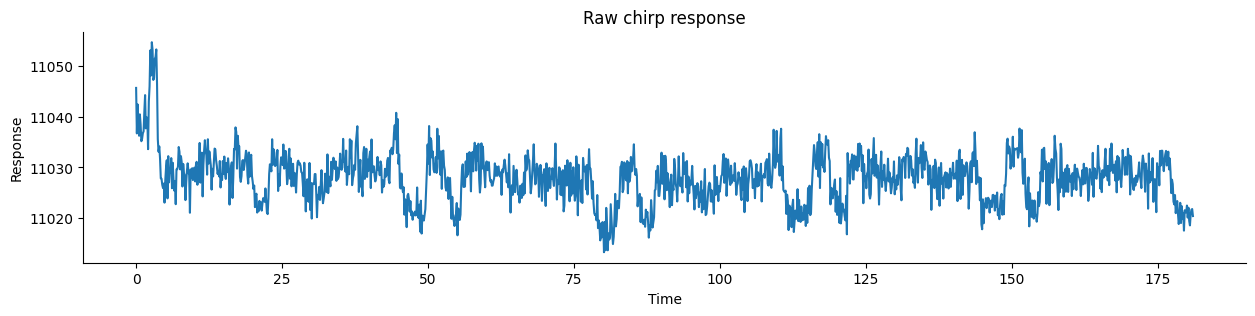

In [44]:
plt.figure(figsize=(15,3))
plt.plot(raw_time, trace)
plt.title('Raw chirp response')
plt.ylabel('Response')
plt.xlabel('Time')
sns.despine()

#### Looking at single trials

In [45]:
#raw trace cut into its five trials
trials = df['chirp_snippets'][0]
trials

array([[-0.44570291,  0.02754068,  0.65194756,  0.47460458, -0.29284382],
       [-0.02992407, -0.02754068,  0.16196167, -0.04299131,  0.08812743],
       [-0.18516821,  0.08770519, -0.69463277, -0.22360149,  0.09299251],
       ...,
       [-0.81058204,  0.22535676,  0.91527164,  0.37342259,  0.09993845],
       [-1.07741904, -0.6693356 , -0.09407771,  0.38096777, -0.46270156],
       [-0.88326383,  0.675569  ,  0.57672393,  0.17784712,  0.18756434]],
      shape=(259, 5))

In [46]:
#time delta between samples
dt_trial = df['chirp_snippets_dt'][0]
dt_trial

np.float64(0.128)

In [47]:
### duration of a single chirp trial
dt_trial * len(trials)

np.float64(33.152)

In [48]:
time = np.arange(0,stop=dt_trial*len(trials),step=dt_trial)

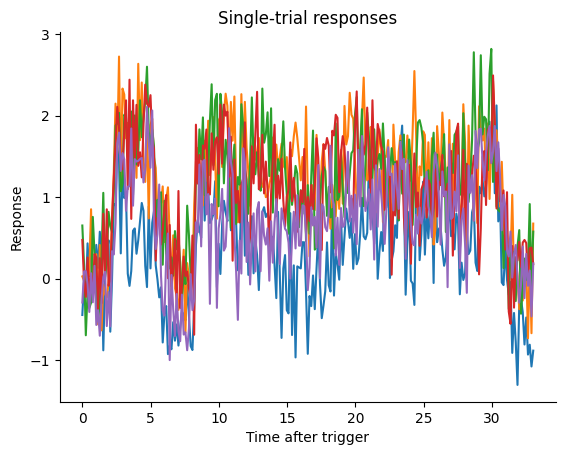

In [49]:
plt.plot(time,trials)
sns.despine()
plt.title('Single-trial responses')
plt.ylabel('Response')
plt.xlabel('Time after trigger')
plt.show()

### Averaged & normalized response

In [50]:
average = df['chirp_average_norm'][0]

In [51]:
avg_dt = df['chirp_average_dt'][0]

In [52]:
time_avg = np.arange(0,stop=avg_dt*len(average),step=avg_dt)

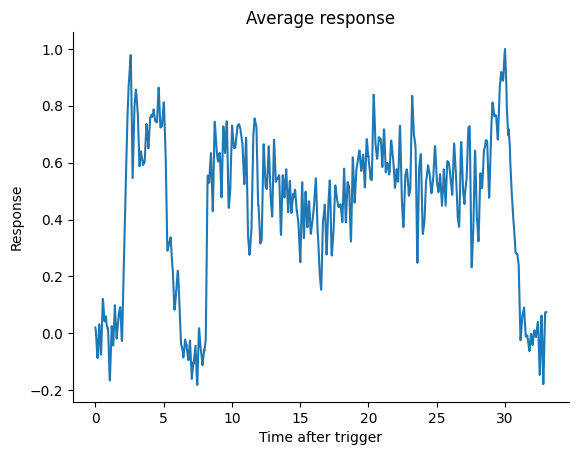

In [53]:
plt.plot(time_avg,average)
plt.title('Average response')
plt.ylabel('Response')
plt.xlabel('Time after trigger')
sns.despine()

# Plot data

In [54]:
row = df.iloc[0]

In [55]:
chirp_time = np.arange(row.chirp_trace.size) * row.chirp_trace_dt + row.chirp_trace_t0
bar_time = np.arange(row.bar_trace.size) * row.bar_trace_dt + row.bar_trace_t0
mc_time = np.arange(row.mc_trace.size) * row.mc_trace_dt + row.mc_trace_t0

In [56]:
from eyewire2_functional_analysis.plot import plot_chirp, plot_bar

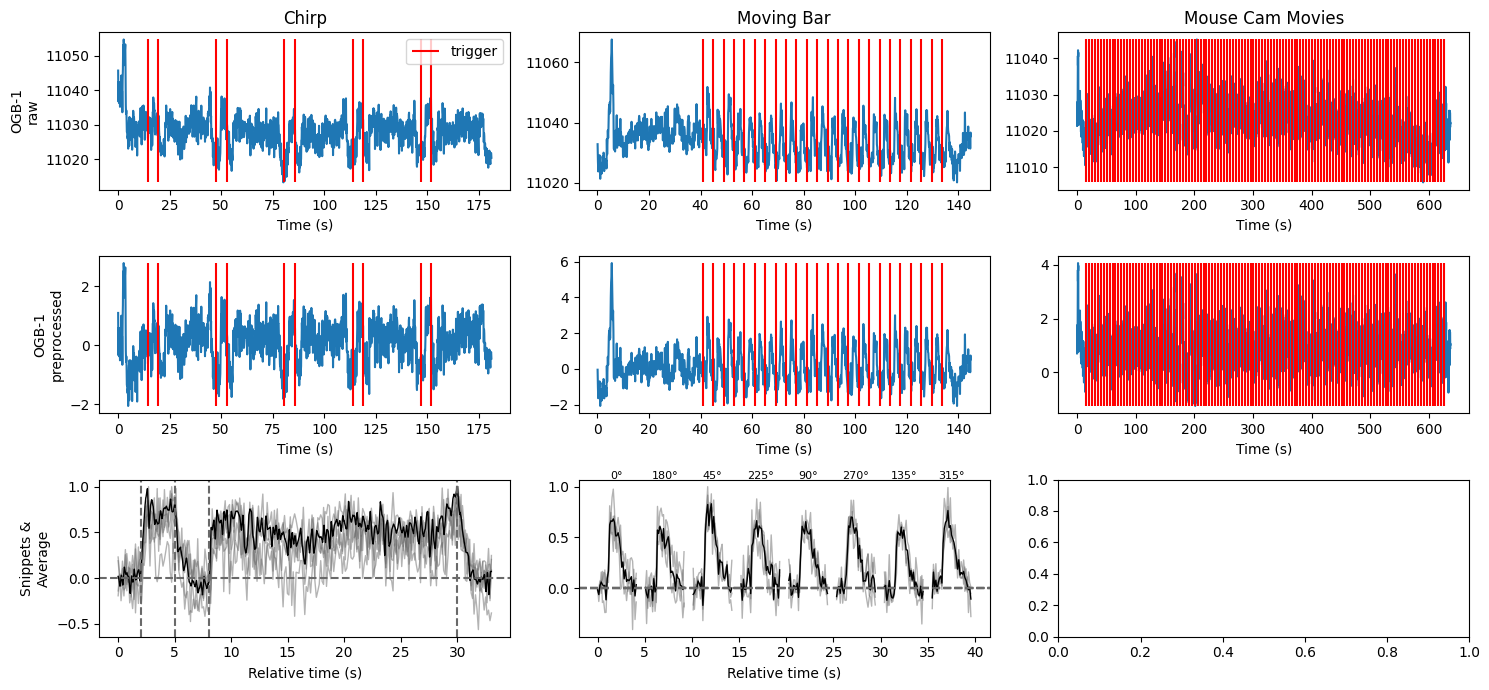

In [57]:
fig, axs = plt.subplots(3, 3, figsize=(15, 7))

# Raw
ax = axs[0, 0]
ax.plot(chirp_time, row.chirp_trace)
ax.vlines(row.chirp_triggertimes_snippets.flatten(), ymin=row.chirp_trace.min(), ymax=row.chirp_trace.max(), color='r',
          label='trigger')
ax.set(xlabel='Time (s)', ylabel='OGB-1\nraw', title='Chirp')
ax.legend(loc='upper right')

ax = axs[0, 1]
ax.plot(bar_time, row.bar_trace)
ax.vlines(row.bar_triggertimes_snippets.flatten(), ymin=row.bar_trace.min(), ymax=row.bar_trace.max(), color='r')
ax.set(xlabel='Time (s)', title='Moving Bar')

ax = axs[0, 2]
ax.plot(mc_time, row.mc_trace)
ax.vlines(row.mc_triggertimes.flatten(), ymin=row.mc_trace.min(), ymax=row.mc_trace.max(), color='r')
ax.set(xlabel='Time (s)', title='Mouse Cam Movies')

# Preprocessed
ax = axs[1, 0]
ax.plot(chirp_time, row.chirp_pp_trace)
ax.vlines(row.chirp_triggertimes_snippets.flatten(), ymin=row.chirp_pp_trace.min(), ymax=row.chirp_pp_trace.max(),
          color='r')
ax.set(xlabel='Time (s)', ylabel='OGB-1\npreprocessed')

ax = axs[1, 1]
ax.plot(bar_time, row.bar_pp_trace)
ax.vlines(row.bar_triggertimes_snippets.flatten(), ymin=row.bar_pp_trace.min(), ymax=row.bar_pp_trace.max(), color='r')
ax.set(xlabel='Time (s)')

ax = axs[1, 2]
ax.plot(mc_time, row.mc_pp_trace)
ax.vlines(row.mc_triggertimes.flatten(), ymin=row.mc_pp_trace.min(), ymax=row.mc_pp_trace.max(), color='r')
ax.set(xlabel='Time (s)')

# Average and repeats
ax = axs[2, 0]
plot_chirp(ax=ax, row=row, stimulus_ms=None, plot_hline=True, plot_vlines=True)
ax.set(xlabel='Relative time (s)', ylabel='Snippets &\nAverage')

ax = axs[2, 1]
plot_bar(ax=ax, row=row, annotate_dirs=True, annotate_symbols=False, ventral_up=True)
ax.set(xlabel='Relative time (s)')

plt.tight_layout()